In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("cell2celltrain.csv")

df.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [4]:
df.columns

Index(['CustomerID', 'Churn', 'MonthlyRevenue', 'MonthlyMinutes',
       'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes',
       'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues',
       'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls',
       'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls',
       'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls',
       'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService',
       'UniqueSubs', 'ActiveSubs', 'ServiceArea', 'Handsets', 'HandsetModels',
       'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'ChildrenInHH',
       'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner',
       'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers',
       'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard',
       'RetentionCalls', 'RetentionOffersAccepted', 'NewCellphoneUser',
       'NotNewCellphoneUser', 'ReferralsMadeBySubscriber', 'IncomeGro

In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [6]:
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')


In [7]:
df[num_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   MonthlyRevenue             50891 non-null  float64
 2   MonthlyMinutes             50891 non-null  float64
 3   TotalRecurringCharge       50891 non-null  float64
 4   DirectorAssistedCalls      50891 non-null  float64
 5   OverageMinutes             50891 non-null  float64
 6   RoamingCalls               50891 non-null  float64
 7   PercChangeMinutes          50680 non-null  float64
 8   PercChangeRevenues         50680 non-null  float64
 9   DroppedCalls               51047 non-null  float64
 10  BlockedCalls               51047 non-null  float64
 11  UnansweredCalls            51047 non-null  float64
 12  CustomerCareCalls          51047 non-null  float64
 13  ThreewayCalls              51047 non-null  flo

In [8]:
df[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Churn                    51047 non-null  object
 1   ServiceArea              51023 non-null  object
 2   ChildrenInHH             51047 non-null  object
 3   HandsetRefurbished       51047 non-null  object
 4   HandsetWebCapable        51047 non-null  object
 5   TruckOwner               51047 non-null  object
 6   RVOwner                  51047 non-null  object
 7   Homeownership            51047 non-null  object
 8   BuysViaMailOrder         51047 non-null  object
 9   RespondsToMailOffers     51047 non-null  object
 10  OptOutMailings           51047 non-null  object
 11  NonUSTravel              51047 non-null  object
 12  OwnsComputer             51047 non-null  object
 13  HasCreditCard            51047 non-null  object
 14  NewCellphoneUser         51047 non-nul

In [9]:
df[cat_cols] = df[cat_cols].apply(lambda x: x.str.strip().str.title())


In [10]:
df[df["HandsetPrice"]=="Unknown"]

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
28,3000174,Yes,16.14,4.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,6,No,0,Unknown,No,1-Highest,Suburban,Professional,Yes
36,3000230,No,20.18,1.0,20.0,0.00,0.0,0.0,0.0,-0.2,...,0,7,No,0,Unknown,No,1-Highest,Town,Other,No
38,3000238,No,37.99,71.0,38.0,0.00,0.0,0.0,146.0,0.0,...,0,7,No,0,Unknown,No,1-Highest,Other,Other,Yes
43,3000290,No,17.43,20.0,17.0,0.00,1.0,0.0,15.0,1.3,...,0,4,No,0,Unknown,No,4-Medium,Town,Other,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51033,3399882,Yes,38.34,320.0,30.0,0.99,21.0,0.0,-66.0,-8.3,...,0,6,No,0,Unknown,No,1-Highest,Other,Professional,No
51035,3399894,No,0.00,76.0,30.0,0.00,0.0,0.0,0.0,0.0,...,0,4,No,0,Unknown,No,2-High,Other,Professional,No
51037,3399906,No,31.92,63.0,17.0,0.00,43.0,0.0,-38.0,-13.2,...,0,3,No,0,Unknown,No,3-Good,Other,Other,Yes
51039,3399922,No,50.00,492.0,50.0,0.00,0.0,0.0,0.0,0.0,...,0,0,No,0,Unknown,No,6-Verylow,Suburban,Other,Unknown


In [11]:
df["HandsetPrice"] = df["HandsetPrice"].apply(pd.to_numeric, errors='coerce')

In [12]:
df["HandsetPrice"].isna().sum()

np.int64(28982)

In [13]:
df["HandsetPrice"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 51047 entries, 0 to 51046
Series name: HandsetPrice
Non-Null Count  Dtype  
--------------  -----  
22065 non-null  float64
dtypes: float64(1)
memory usage: 398.9 KB


KNN IMPUTATION-Avoid on massive datasets, as calculating the distance between all points is computationally expensive and slow. 

In [14]:
df['HandsetPrice'] = df.groupby('IncomeGroup')['HandsetPrice'].transform(
    lambda x: x.fillna(x.median())
)

So this is ordinal ranking of income

In [15]:
print(df["IncomeGroup"].unique())

[4 5 6 9 1 7 3 0 8 2]


In [16]:
print(df["CreditRating"].unique())

['1-Highest' '4-Medium' '3-Good' '6-Verylow' '2-High' '5-Low' '7-Lowest']


In [17]:

df['CreditRating'] = df['CreditRating'].str.extract('(\d+)').astype(int)
df['CreditRating'] = df['CreditRating'].max() + 1 - df['CreditRating']

In [18]:
print(df["CreditRating"].unique())

[7 4 5 2 6 3 1]


In [19]:
df[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Churn                    51047 non-null  object 
 1   ServiceArea              51023 non-null  object 
 2   ChildrenInHH             51047 non-null  object 
 3   HandsetRefurbished       51047 non-null  object 
 4   HandsetWebCapable        51047 non-null  object 
 5   TruckOwner               51047 non-null  object 
 6   RVOwner                  51047 non-null  object 
 7   Homeownership            51047 non-null  object 
 8   BuysViaMailOrder         51047 non-null  object 
 9   RespondsToMailOffers     51047 non-null  object 
 10  OptOutMailings           51047 non-null  object 
 11  NonUSTravel              51047 non-null  object 
 12  OwnsComputer             51047 non-null  object 
 13  HasCreditCard            51047 non-null  object 
 14  NewCellphoneUser      

In [20]:
df.isna().sum()

CustomerID                     0
Churn                          0
MonthlyRevenue               156
MonthlyMinutes               156
TotalRecurringCharge         156
DirectorAssistedCalls        156
OverageMinutes               156
RoamingCalls                 156
PercChangeMinutes            367
PercChangeRevenues           367
DroppedCalls                   0
BlockedCalls                   0
UnansweredCalls                0
CustomerCareCalls              0
ThreewayCalls                  0
ReceivedCalls                  0
OutboundCalls                  0
InboundCalls                   0
PeakCallsInOut                 0
OffPeakCallsInOut              0
DroppedBlockedCalls            0
CallForwardingCalls            0
CallWaitingCalls               0
MonthsInService                0
UniqueSubs                     0
ActiveSubs                     0
ServiceArea                   24
Handsets                       1
HandsetModels                  1
CurrentEquipmentDays           1
AgeHH1    

In [21]:
(df.isnull().any(axis=1).sum() / len(df)) * 100
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

In [22]:
cols_to_drop = [col for col in df.columns if df[col].nunique() <= 1] 
cols_to_drop

[]

In [23]:
df = df.dropna()

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49752 entries, 0 to 51043
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 49752 non-null  int64  
 1   Churn                      49752 non-null  object 
 2   MonthlyRevenue             49752 non-null  float64
 3   MonthlyMinutes             49752 non-null  float64
 4   TotalRecurringCharge       49752 non-null  float64
 5   DirectorAssistedCalls      49752 non-null  float64
 6   OverageMinutes             49752 non-null  float64
 7   RoamingCalls               49752 non-null  float64
 8   PercChangeMinutes          49752 non-null  float64
 9   PercChangeRevenues         49752 non-null  float64
 10  DroppedCalls               49752 non-null  float64
 11  BlockedCalls               49752 non-null  float64
 12  UnansweredCalls            49752 non-null  float64
 13  CustomerCareCalls          49752 non-null  float64


In [25]:
for col in cat_cols:
    print(col,df[col].unique())

Churn ['Yes' 'No']
ServiceArea ['Seapor503' 'Pithom412' 'Milmil414' 'Okctul918' 'Okcokc405' 'Sanmca210'
 'Slcslc801' 'Loulou502' 'Kcykck913' 'Kcynew316' 'Kcykcm816' 'Denden303'
 'Phictr610' 'Okclrk501' 'Omades515' 'Sanaus512' 'Kcywic316' 'Indind317'
 'Slcpro801' 'Omalnc402' 'Nshnsh615' 'Omaoma402' 'Phxtuc520' 'Daldal214'
 'Daldtn940' 'Dalftw817' 'Sansan210' 'Nycman917' 'Nolken504' 'Minmin612'
 'Phiard610' 'Nycque917' 'Denbou303' 'Bosbos617' 'Phxphx602' 'Nnybuf716'
 'Nnysyr315' 'Stlstl314' 'Phiphi215' 'Dettol419' 'Seablv425' 'Miamia305'
 'Phichc215' 'Seasea206' 'Birbir205' 'Miadfd954' 'Lounal812' 'Miadel561'
 'Miaftl954' 'Seaspo509' 'Seatac253' 'Nnyroc716' 'Sfrsac916' 'Mianda305'
 'Minstp612' 'Miahwd954' 'Nycbro917' 'Phijen215' 'Omacdr319' 'Miawpb561'
 'Seaoly360' 'Pitbut412' 'Seaeve425' 'Phimer609' 'Seacda208' 'Harhar860'
 'Sfrsfr415' 'Sfroak510' 'Sfrscl408' 'Nnyalb518' 'Stlcol618' 'Nycnew201'
 'Sfrpal650' 'Detdet313' 'Detros810' 'Nycnew908' 'Nycnas516' 'Nshcol615'
 'Pitgre412' 'Seabea

In [26]:
binary_cols = [
    'ChildrenInHH','HandsetRefurbished','HandsetWebCapable',
    'TruckOwner','RVOwner','BuysViaMailOrder','RespondsToMailOffers',
    'OptOutMailings','NonUSTravel','OwnsComputer','HasCreditCard',
    'NewCellphoneUser','NotNewCellphoneUser','OwnsMotorcycle',
    'MadeCallToRetentionTeam','Churn'
]

df[binary_cols] = df[binary_cols].replace({'Yes':1, 'No':0})

C:\Users\lenovo\AppData\Local\Temp\ipykernel_18104\1338416990.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'Yes':1, 'No':0})


In [27]:
df.drop(columns=['NotNewCellphoneUser','CustomerID'], inplace=True)

In [28]:
df['Homeownership'] = df['Homeownership'].map({'Known':1, 'Unknown':0})

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49752 entries, 0 to 51043
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      49752 non-null  int64  
 1   MonthlyRevenue             49752 non-null  float64
 2   MonthlyMinutes             49752 non-null  float64
 3   TotalRecurringCharge       49752 non-null  float64
 4   DirectorAssistedCalls      49752 non-null  float64
 5   OverageMinutes             49752 non-null  float64
 6   RoamingCalls               49752 non-null  float64
 7   PercChangeMinutes          49752 non-null  float64
 8   PercChangeRevenues         49752 non-null  float64
 9   DroppedCalls               49752 non-null  float64
 10  BlockedCalls               49752 non-null  float64
 11  UnansweredCalls            49752 non-null  float64
 12  CustomerCareCalls          49752 non-null  float64
 13  ThreewayCalls              49752 non-null  float64


In [32]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(df['CallForwardingCalls'].unique())
print(df['CallForwardingCalls'].value_counts())

[ 0.   0.3  0.7  2.  23.7  1.7  1.  51.7  9.7 16.   1.3  3.7  2.7  2.3
 26.3  4.   6.3 31.3  5.  11.   3.   8.7 10.7 22.  12.   5.3 21.  55.7
 81.3 12.3]
CallForwardingCalls
0.0     49526
0.3        99
0.7        48
1.0        18
2.0        13
1.3        10
2.3         7
1.7         4
3.7         3
2.7         2
5.0         2
4.0         2
23.7        1
16.0        1
9.7         1
51.7        1
6.3         1
26.3        1
31.3        1
11.0        1
3.0         1
8.7         1
10.7        1
22.0        1
12.0        1
5.3         1
21.0        1
55.7        1
81.3        1
12.3        1
Name: count, dtype: int64


In [33]:
df['TotalCalls'] = df['InboundCalls'] + df['OutboundCalls']
df['MinutesPerCall'] = df['MonthlyMinutes'] / (df['TotalCalls'] + 1)
df['CallsPerDay'] = df['TotalCalls'] / (df['MonthsInService'] + 1)
df['UnansweredRate'] = df['UnansweredCalls'] / (df['TotalCalls'] + 1)
df['FailureRate'] = (df['DroppedCalls'] + df['BlockedCalls']) / (df['TotalCalls'] + 1)
df['CostPerMinute'] = df['MonthlyRevenue'] / (df['MonthlyMinutes'] + 1)
df['OverageRatio'] = df['OverageMinutes'] / (df['MonthlyMinutes'] + 1)
df['ComplaintRate'] = df['CustomerCareCalls'] / (df['TotalCalls'] + 1)
df['RetentionSuccessRate'] = df['RetentionOffersAccepted'] / (df['RetentionCalls'] + 1)
df['RetentionContacted'] = (df['RetentionCalls'] > 0).astype(int)
pd.crosstab(df['RetentionOffersAccepted'],df['Churn'] )

Churn,0,1
RetentionOffersAccepted,,
0,34997,13895
1,485,331
2,20,16
3,5,3


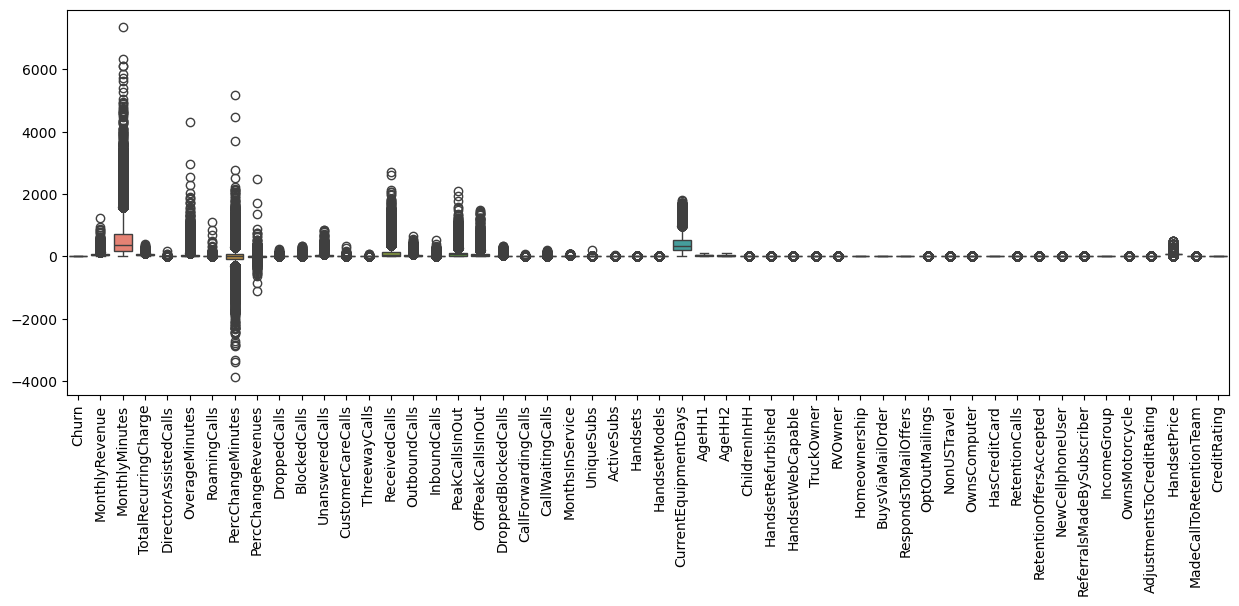

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.show()


In [35]:
def detect_outliers(df, cols):
    outlier_cols = []

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # check if any value outside bounds
        if ((df[col] < lower) | (df[col] > upper)).any():
            outlier_cols.append(col)

    return outlier_cols

In [36]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
# remove binary / low-unique columns
num_cols = [col for col in num_cols if df[col].nunique() > 20]
outlier_cols = detect_outliers(df, num_cols)


print("Columns with outliers:")
print(outlier_cols)

Columns with outliers:
['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'Handsets', 'CurrentEquipmentDays', 'TotalCalls', 'MinutesPerCall', 'CallsPerDay', 'UnansweredRate', 'FailureRate', 'CostPerMinute', 'OverageRatio', 'ComplaintRate']


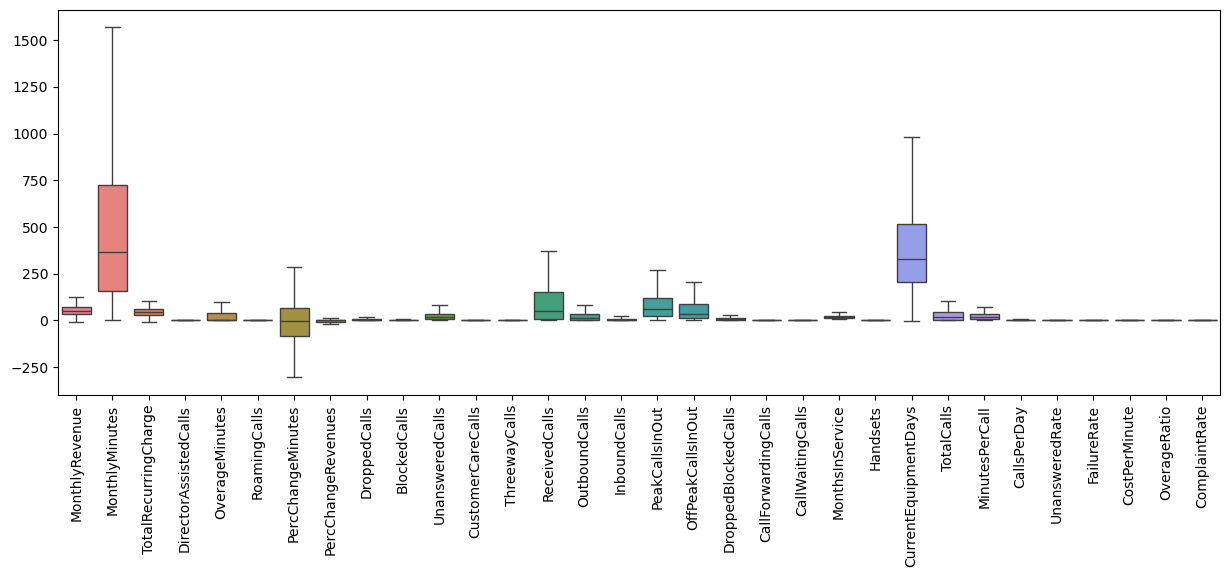

In [37]:
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
sns.boxplot(data=df[outlier_cols])
plt.xticks(rotation=90)
plt.show()

In [38]:
corr_matrix = df.corr(numeric_only=True)

In [39]:
corr_with_churn = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
print(corr_with_churn)

Churn                      1.000000
CurrentEquipmentDays       0.104082
CostPerMinute              0.075801
MadeCallToRetentionTeam    0.060577
RetentionContacted         0.060577
                             ...   
CustomerCareCalls         -0.049853
MonthlyMinutes            -0.052908
TotalRecurringCharge      -0.062125
HandsetWebCapable         -0.062409
CallForwardingCalls             NaN
Name: Churn, Length: 62, dtype: float64


In [40]:
corr_df = corr_with_churn.reset_index()
corr_df.columns = ['Feature', 'Correlation_with_Churn']
print(corr_df)

                    Feature  Correlation_with_Churn
0                     Churn                1.000000
1      CurrentEquipmentDays                0.104082
2             CostPerMinute                0.075801
3   MadeCallToRetentionTeam                0.060577
4        RetentionContacted                0.060577
..                      ...                     ...
57        CustomerCareCalls               -0.049853
58           MonthlyMinutes               -0.052908
59     TotalRecurringCharge               -0.062125
60        HandsetWebCapable               -0.062409
61      CallForwardingCalls                     NaN

[62 rows x 2 columns]


In [41]:
corr_df[abs(corr_df['Correlation_with_Churn']) > 0.04]

,Feature,Correlation_with_Churn
0,Churn,1.000000
1,CurrentEquipmentDays,0.104082
2,CostPerMinute,0.075801
3,MadeCallToRetentionTeam,0.060577
4,RetentionContacted,0.060577
5,RetentionCalls,0.058422
6,OverageRatio,0.052045
7,CreditRating,0.047741
50,TotalCalls,-0.040300
51,HandsetModels,-0.040470


In [42]:
# correlation matrix
corr_matrix = df.corr(numeric_only=True).abs()

# upper triangle (to avoid duplicates)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# get pairs with correlation > 0.8
high_corr_pairs = []

for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] > 0.8:
            high_corr_pairs.append((row, col, upper.loc[row, col]))

# print results
for pair in high_corr_pairs:
    print(f"{pair[0]}  <--->  {pair[1]}  =  {pair[2]:.2f}")

MonthlyMinutes  <--->  ReceivedCalls  =  0.83
ReceivedCalls  <--->  OffPeakCallsInOut  =  0.80
DroppedCalls  <--->  DroppedBlockedCalls  =  0.83
Handsets  <--->  HandsetModels  =  0.84
BuysViaMailOrder  <--->  RespondsToMailOffers  =  0.97
RetentionCalls  <--->  MadeCallToRetentionTeam  =  0.96
OutboundCalls  <--->  TotalCalls  =  0.98
InboundCalls  <--->  TotalCalls  =  0.87
OutboundCalls  <--->  CallsPerDay  =  0.89
TotalCalls  <--->  CallsPerDay  =  0.91
OverageMinutes  <--->  OverageRatio  =  0.83
CustomerCareCalls  <--->  ComplaintRate  =  0.80
RetentionOffersAccepted  <--->  RetentionSuccessRate  =  0.98
RetentionCalls  <--->  RetentionContacted  =  0.96
MadeCallToRetentionTeam  <--->  RetentionContacted  =  1.00


In [43]:
df.drop(columns=['TotalCalls','RetentionCalls','MadeCallToRetentionTeam','RetentionOffersAccepted','DroppedCalls','CustomerCareCalls'
                 ,'OverageMinutes','Handsets','BuysViaMailOrder','ReceivedCalls','CallForwardingCalls','ServiceArea'], inplace=True)

df.drop(columns=[
    'MonthlyRevenue',
    'MonthlyMinutes',
    'OutboundCalls',
    'PeakCallsInOut',
    'OffPeakCallsInOut',
    'UniqueSubs',
    'AgeHH2',
    'UnansweredCalls',
    'HasCreditCard'
], inplace=True)

In [44]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

In [45]:
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(exclude='object').columns

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [47]:
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

In [48]:
from sklearn.preprocessing import RobustScaler,StandardScaler

scaler = RobustScaler(with_centering=False)

X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

Best number of features: 26
Best recall: 0.03097626690684588


IndexError: boolean index did not match indexed array along axis 0; size of axis is 44 but size of corresponding boolean axis is 53

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector

# define final selector
sfs_final = SequentialFeatureSelector(
    LogisticRegression(max_iter=1000),
    n_features_to_select=26,
    direction='forward'
)

# transform data
X_train_final = sfs_final.fit_transform(X_train_scaled, y_train)
X_test_final = sfs_final.transform(X_test_scaled)

model = LogisticRegression(max_iter=1000)

# train
model.fit(X_train_final, y_train)

# predict
y_pred = model.predict(X_test_final)

In [52]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.7137976082805748
Recall: 0.009126009126009126
F1: 0.01793103448275862


In [53]:
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTEENN, SMOTETomek
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

strategies = {
    "Baseline": None,
    "Random Under": RandomUnderSampler(random_state=42),
    "Tomek Links": TomekLinks(),
    "Random Over": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "SMOTE-Tomek": SMOTETomek(random_state=42),
    "SMOTE-ENN": SMOTEENN(random_state=42)
}

results = []

for name, sampler in strategies.items():

    if sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train_final, y_train)
    else:
        X_res, y_res = X_train_final, y_train

    model = LogisticRegression(max_iter=1000)

    model.fit(X_res, y_res)

    y_pred = model.predict(X_test_final)

    results.append({
        "Technique": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "F1 Score": round(f1_score(y_test, y_pred), 3)
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values(by="Recall", ascending=False))

      Technique  Accuracy  Recall  F1 Score
7     SMOTE-ENN     0.329   0.946     0.447
5        ADASYN     0.548   0.556     0.413
6   SMOTE-Tomek     0.555   0.540     0.410
4         SMOTE     0.558   0.537     0.410
1  Random Under     0.562   0.528     0.408
3   Random Over     0.568   0.515     0.406
2   Tomek Links     0.714   0.017     0.033
0      Baseline     0.714   0.009     0.018


In [54]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.32941412923324287
Recall: 0.9455949455949456
F1: 0.4467291269380648


In [55]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',              # non-linear
    C=1,
    gamma='scale',
  
)

svm.fit(X_res, y_res)

SVC(C=1)

In [56]:
y_pred = svm.predict(X_test_final)

In [57]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.31956587277660536
Recall: 0.9634959634959634
F1: 0.44776119402985076


In [58]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
import pandas as pd

k_range = range(1, 21)
weights_options = ['uniform', 'distance']
metric_options = ['euclidean', 'manhattan']

results = []

for k in k_range:
    for w in weights_options:
        for m in metric_options:
            
            knn = KNeighborsClassifier(
                n_neighbors=k,
                weights=w,
                metric=m
            )
            
            knn.fit(X_res, y_res)
            
            y_pred = knn.predict(X_test_final)
            
            acc = accuracy_score(y_test, y_pred)
            rec = recall_score(y_test, y_pred)
            prec = precision_score(y_test,y_pred)
            f1 = f1_score(y_test, y_pred)
            
            results.append({
                'k': k,
                'weights': w,
                'metric': m,
                'Accuracy': acc,
                'Recall': rec,
                'F1': f1
            })

# Convert to DataFrame
results_df = pd.DataFrame(results)
results_df.sort_values(by='Recall', ascending=False)

,k,weights,metric,Accuracy,Recall,F1
72,19,uniform,euclidean,0.381871,0.838891,0.437288
64,17,uniform,euclidean,0.387298,0.827308,0.436037
78,20,distance,euclidean,0.386996,0.823447,0.434766
74,19,distance,euclidean,0.387901,0.820288,0.434185
76,20,uniform,euclidean,0.392423,0.816076,0.434742
...,...,...,...,...,...,...
1,1,uniform,manhattan,0.521053,0.515269,0.381200
3,1,distance,manhattan,0.521053,0.515269,0.381200
7,2,distance,manhattan,0.521053,0.515269,0.381200
4,2,uniform,euclidean,0.532308,0.500878,0.380128
